In [1]:
import torch
import os
from torch import nn
from pytorchcv.model_provider import get_model as ptcv_get_model
from data_utils import get_resnet_imagenet_preprocess

from pathlib import Path

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import scale_cam_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
from PIL import Image
import pickle as pkl

In [2]:
class MyGradCAM(GradCAM):
    target_size = (7, 7,)

    def __init__(self, model, target_layers, reshape_transform=None):
        super(MyGradCAM, self).__init__(model, target_layers, reshape_transform)

    def compute_cam_per_layer(
            self, input_tensor: torch.Tensor, targets: list[torch.nn.Module], eigen_smooth: bool
    ) -> list[np.ndarray]:
        activations_list = [a.cpu().data.numpy() for a in self.activations_and_grads.activations]
        grads_list = [g.cpu().data.numpy() for g in self.activations_and_grads.gradients]

        cam_per_target_layer = []
        # Loop over the saliency image from every layer
        for i in range(len(self.target_layers)):
            target_layer = self.target_layers[i]
            layer_activations = None
            layer_grads = None
            if i < len(activations_list):
                layer_activations = activations_list[i]
            if i < len(grads_list):
                layer_grads = grads_list[i]

            cam = self.get_cam_image(input_tensor, target_layer, targets, layer_activations, layer_grads, eigen_smooth)
            cam = np.maximum(cam, 0)
            scaled = scale_cam_image(cam, self.target_size)
            cam_per_target_layer.append(scaled[:, None, :])

        return cam_per_target_layer

    def aggregate_multi_layers(self, cam_per_target_layer: np.ndarray) -> np.ndarray:
        return np.squeeze(cam_per_target_layer[0])

In [3]:
device = "cpu"
target_model = ptcv_get_model("resnet18_cub", pretrained=True).to(device)
target_model.eval()

ResNet(
  (features): Sequential(
    (init_block): ResInitBlock(
      (conv): ConvBlock(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activ): ReLU(inplace=True)
      )
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (stage1): Sequential(
      (unit1): ResUnit(
        (body): ResBlock(
          (conv1): ConvBlock(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (activ): ReLU(inplace=True)
          )
          (conv2): ConvBlock(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [4]:
weight_b_g = torch.load("saved_models/b_g.pt", map_location="cpu")
weight_W_c = torch.load("saved_models/W_c.pt", map_location="cpu")
weight_W_g = torch.load("saved_models/W_g.pt", map_location="cpu")

proj_layer = torch.nn.Linear(in_features=target_model.output.in_features, out_features=113, bias=False)
final_layer = torch.nn.Linear(113, 200)

In [5]:
proj_layer.weight.data = weight_W_c
final_layer.weight.data = weight_W_g
final_layer.weight.bias = weight_b_g

In [6]:
target_model.output = nn.Sequential(proj_layer, final_layer)

In [7]:
dataset_path = os.path.expanduser("~/Developer/Research/datasets/cub200_cropped/test_cropped/013.Bobolink/")
os.listdir(dataset_path)
img = Image.open(os.path.join(dataset_path, "Bobolink_0070_10624.jpg"))

transforms = get_resnet_imagenet_preprocess()

attribute_path = os.path.expanduser("~/Developer/Research/datasets/CUB_200_2011/attributes")

with open(Path(os.path.expanduser("~/Developer/Research/cbm-loc-enhance"))/ "data" / "CUB" / "class_attr_data_10" / "train.pkl", "rb") as fp:
    train_attribute_anns = pkl.load(fp)

label2attr = dict()
for ann in train_attribute_anns:
    label, attribute_vector = ann["class_label"], ann["attribute_label"]
    if label not in label2attr:
        label2attr[label] = attribute_vector

attributes = torch.tensor([label2attr[i] for i in range(len(label2attr))], dtype=torch.long)

In [ ]:
target_layers = [target_model.features.stage4.unit2.body.conv2.bn]

with MyGradCAM(model=target_model, target_layers=target_layers) as grad_cam:
    cams = dict()
    attrs = attributes[12]

    for i, attr_i in enumerate(attrs):
        if attr_i == 0:
            continue
        else:
            targets = [ClassifierOutputTarget(i)]
            attribute_cam = grad_cam(input_tensor=transforms(img).unsqueeze(0), targets=targets)  # shape: (1, 224, 224)
            cams[i] = attribute_cam


In [14]:
cams.keys()

dict_keys([3, 7, 8, 13, 14, 19, 22, 28, 29, 31, 34, 35, 42, 47, 50, 52, 57, 61, 67, 68, 73, 78, 82, 85, 89, 93, 100, 106, 111])

In [17]:
from pytorch_grad_cam.utils.image import show_cam_on_image
# visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [22]:
visualization = show_cam_on_image(np.float32(np.array(img) / 255), cams[3], use_rgb=True)

ValueError: operands could not be broadcast together with shapes (7,7,3) (158,132,3) 

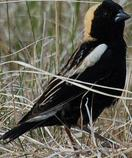

In [25]:
img

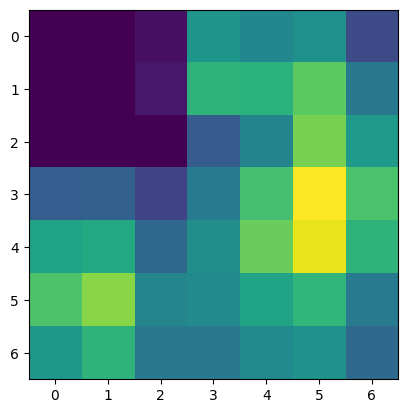

In [24]:
plt.imshow(cams[3])